# ISLES 2022 — Stroke Lesion Segmentation Dataset: Step-by-Step Exploration

This notebook walks you through the **ISLES 2022** dataset from zero, so you understand *what the data is* before training any model.

**Dataset in one paragraph.** 250 brain MRI cases of patients with an ischemic stroke (a blood clot blocking a brain artery). Each case has three MRI images (**DWI**, **ADC**, **FLAIR**) and one expert-drawn **mask** that marks the stroke lesion. Images are 3D volumes in NIfTI format (`.nii.gz`), skull-stripped, in native (unregistered) space, from 3 stroke centers and several scanners.

**Roadmap**

| Step | Question it answers |
|---|---|
| 1 | Where are the files and how are they organised? |
| 2 | Do all 250 cases have all 4 files? |
| 3 | What is inside one NIfTI file (shape, voxel size, orientation)? |
| 4 | What does one case look like? |
| 5 | How different are the scans from each other (size, spacing)? |
| 6 | How big are the lesions? |
| 7 | Which scanners were used, and does it matter? |
| 8 | How do lesions look in DWI / ADC / FLAIR vs healthy tissue? |
| 9 | A gallery of random cases |
| 10 | Summary and what to do next for modelling |

> **Citations:** de la Rosa et al., *DeepISLES*, Nature Communications 16 (2025) 7357 · Hernandez Petzsche et al., *ISLES 2022*, Scientific Data 9 (2022) 762.

## 0. Glossary (read once, refer back later)

| Term | Plain-English meaning |
|---|---|
| **NIfTI** | The standard file format for 3D brain scans (`.nii` / `.nii.gz`). Holds a 3D array + a header with physical information. |
| **Voxel** | A 3D pixel. Its physical size (e.g. 1 x 1 x 5 mm) is stored in the header. |
| **Affine** | A 4x4 matrix that maps voxel index (i,j,k) to real-world millimetre coordinates. |
| **DWI (b=1000)** | Diffusion-weighted image. Acute stroke lesions appear **bright**. |
| **ADC map** | Computed from DWI. True acute lesions appear **dark** (restricted diffusion). Confirms the DWI signal is not an artefact. |
| **FLAIR** | Fluid-attenuated image. Shows older / subacute damage and white-matter disease as **bright**. |
| **Mask / segmentation** | A 3D array with the same grid as the image: `1` = lesion, `0` = everything else. This is what a model must predict. |
| **Skull-stripped** | Skull and face removed, so the background is exactly 0. |
| **BIDS** | A naming convention: `sub-<id>_ses-<id>_<modality>.nii.gz`. |
| **mL** | Lesion volume unit. 1 mL = 1000 mm3 = 1 cm3. |

## 1. Setup and configuration

The only thing you may need to edit is `DATA_ROOT`. Point it at the folder that contains the ISLES-2022 files (the code searches inside it recursively, so the exact sub-folder layout does not matter).

In [1]:
# If a library is missing, uncomment:
# !pip install -q nibabel scipy seaborn pandas matplotlib tqdm

import os, re, json, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from nibabel.processing import resample_from_to
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# ------------------------- EDIT HERE -------------------------
DATA_ROOT = "/kaggle/input/datasets/prosenjitmondol/a-stroke-lesion-segmentation-dataset/ISLES-2022"
MAX_CASES = None      # e.g. 30 for a quick test run; None = use all cases
SEED = 42
# --------------------------------------------------------------

# if the path above is wrong, look for an ISLES-2022 folder anywhere under /kaggle/input
if not os.path.isdir(DATA_ROOT):
    import glob
    hits = glob.glob("/kaggle/input/**/ISLES-2022", recursive=True)
    if hits:
        DATA_ROOT = hits[0]

rng = np.random.default_rng(SEED)
print("Data root:", DATA_ROOT, "| exists:", os.path.isdir(DATA_ROOT))

Data root: /kaggle/input/datasets/prosenjitmondol/a-stroke-lesion-segmentation-dataset/ISLES-2022 | exists: True


## 2. Folder structure

ISLES-2022 follows BIDS. **In your Kaggle copy** the layout looks like this (see your screenshot):

```
ISLES-2022/
├── sub-strokecase0001/ses-0001/
│      ├── anat/  sub-..._FLAIR.nii   (+ FLAIR.json)
│      └── dwi/   sub-..._adc.nii/    <- a FOLDER named like a file, with the real image inside
│                 sub-..._dwi.nii/    <- same here
│                 sub-..._adc.json, sub-..._dwi.json
└── derivatives/sub-strokecase0001/ses-0001/   ... expert mask (msk)
```

> ⚠️ **Why the old code failed:** the DWI and ADC images sit *inside folders* whose name ends in `.nii`, and the real file inside has a different name (`sub-strokeperf0041_ses-20180528_ornt-2iso_skull…`). The old code looked only at file names, so it never found a file called `..._dwi`, and the table had no `dwi` column → `KeyError: ['dwi']`.
> The new code reads the **folder path** to decide which patient and which modality a file belongs to.

Let's look at your copy. First the top levels, then one complete patient in detail.

In [2]:
def show_tree(root, max_depth=2, max_items=6):
    root = root.rstrip("/")
    base_depth = root.count(os.sep)
    for dirpath, dirs, files in os.walk(root):
        depth = dirpath.count(os.sep) - base_depth
        if depth > max_depth:
            dirs[:] = []
            continue
        dirs.sort()
        print("  " * depth + "📁 " + os.path.basename(dirpath) + f"  ({len(dirs)} folders, {len(files)} files)")
        for f in sorted(files)[:max_items]:
            print("  " * (depth + 1) + "📄 " + f)
        dirs[:] = dirs[:max_items]

show_tree(DATA_ROOT)

print("\n" + "=" * 70 + "\nOne complete patient, all levels:\n")
case_dir = os.path.join(DATA_ROOT, "sub-strokecase0001")
if os.path.isdir(case_dir):
    show_tree(case_dir, max_depth=6, max_items=10)

📁 ISLES-2022  (251 folders, 4 files)
  📄 LICENSE
  📄 README
  📄 dataset_description.json
  📄 participants.tsv
  📁 derivatives  (250 folders, 0 files)
    📁 sub-strokecase0001  (1 folders, 0 files)
    📁 sub-strokecase0002  (1 folders, 0 files)
    📁 sub-strokecase0003  (1 folders, 0 files)
    📁 sub-strokecase0004  (1 folders, 0 files)
    📁 sub-strokecase0005  (1 folders, 0 files)
    📁 sub-strokecase0006  (1 folders, 0 files)
  📁 sub-strokecase0001  (1 folders, 0 files)
    📁 ses-0001  (2 folders, 0 files)
  📁 sub-strokecase0002  (1 folders, 0 files)
    📁 ses-0001  (2 folders, 0 files)
  📁 sub-strokecase0003  (1 folders, 0 files)
    📁 ses-0001  (2 folders, 0 files)
  📁 sub-strokecase0004  (1 folders, 0 files)
    📁 ses-0001  (2 folders, 0 files)
  📁 sub-strokecase0005  (1 folders, 0 files)
    📁 ses-0001  (2 folders, 0 files)

One complete patient, all levels:

📁 sub-strokecase0001  (1 folders, 0 files)
  📁 ses-0001  (2 folders, 0 files)
    📁 anat  (0 folders, 2 files)
      📄 sub

## 3. Build one table: one row per patient

We scan every file once and decide **from its folder path** (not only its name) which patient it belongs to (`sub-strokecaseXXXX` folder) and which image it is (`dwi`, `adc`, `flair`, `msk`). This also handles the `*.nii` folders that contain the real image. The result is a **DataFrame with columns `dwi`, `adc`, `flair`, `msk`** (file paths) — every later step just uses this table.

In [3]:
import gzip

NII_EXT  = (".nii.gz", ".nii")
SUBJ_DIR = re.compile(r"^sub-[A-Za-z0-9]+$")     # a folder called exactly  sub-strokecase0001
SES_DIR  = re.compile(r"^ses-[A-Za-z0-9]+$")     # a folder called exactly  ses-0001

def detect_modality(text):
    """Return 'dwi' | 'adc' | 'flair' | 'msk' | None, judging only by the words inside `text`."""
    words = set(re.split(r"[^a-z0-9]+", text.lower()))
    if words & {"msk", "mask", "lesion", "seg", "segmentation", "label"}: return "msk"
    if "flair" in words: return "flair"
    if "adc"   in words: return "adc"
    if "dwi"   in words: return "dwi"
    return None

def classify(path, root):
    """Work out (subject, session, modality, file type) of one file from its PATH.

    Why the path and not only the file name?  In this Kaggle copy some scans are stored as
        dwi/sub-strokecase0001_ses-0001_dwi.nii/   <- a FOLDER that only *looks* like a file
            sub-strokeperf0041_ses-20180528_ornt-2iso_skull....nii.gz   <- the real image, odd name
    so the real file name is not reliable. The folder names are.
    """
    parts   = os.path.relpath(path, root).split(os.sep)
    folders = parts[:-1]
    fname   = parts[-1]
    is_json = fname.lower().endswith(".json")

    subject = next((p for p in folders if SUBJ_DIR.match(p)), None)
    session = next((p for p in folders if SES_DIR.match(p)), None)
    if subject is None:                                    # fall back to the file name
        m = re.search(r"(sub-[A-Za-z0-9]+)", fname)
        subject = m.group(1) if m else None

    wrappers = [p for p in folders if p.lower().endswith(NII_EXT)]      # folders named *.nii
    kind = None
    for text in wrappers[::-1] + [fname]:                  # wrapper folder first, then file name
        kind = detect_modality(text)
        if kind: break

    return dict(subject=subject, session=session, kind=kind,
                ext="json" if is_json else "nifti",
                in_deriv=any(p.lower() == "derivatives" for p in folders),
                path=path)

def index_dataset(root):
    """Walk the folder tree once and return a DataFrame with one row per .nii / .nii.gz / .json file."""
    rows = []
    for dirpath, _, files in os.walk(root, followlinks=True):
        for f in files:
            if f.lower().endswith(NII_EXT + (".json",)):
                rows.append(classify(os.path.join(dirpath, f), root))
    return pd.DataFrame(rows)

def load_nifti(path):
    """nib.load(), but also copes with gzip data hiding behind a plain '.nii' file name."""
    try:
        return nib.load(path)
    except Exception:
        with open(path, "rb") as fh:
            gz = fh.read(2) == b"\x1f\x8b"
        if not gz: raise
        with gzip.open(path, "rb") as g:
            return nib.Nifti1Image.from_bytes(g.read())

files_df = index_dataset(DATA_ROOT)
print("Total image/json files found:", len(files_df))
print("\nFiles per modality / type   (kind = None means 'could not recognise'):")
print(files_df.assign(kind=files_df.kind.fillna("None"))
              .groupby(["kind", "ext"]).size().unstack(fill_value=0))

Total image/json files found: 1433

Files per modality / type   (kind = None means 'could not recognise'):
ext    json  nifti
kind              
None      1      0
adc     144    250
dwi     144    250
flair   144    250
msk       0    250


In [4]:
needed = ["dwi", "adc", "flair", "msk"]

def build_case_table(files_df):
    nii = files_df[(files_df.ext == "nifti") & files_df.kind.notna() & files_df.subject.notna()].copy()
    nii = nii[nii.path.map(os.path.getsize) > 0]                    # ignore empty files
    # if a modality exists twice, prefer the mask from derivatives/ and the images from outside it
    nii["rank"] = np.where((nii.kind == "msk") == nii.in_deriv, 0, 1)
    nii = nii.sort_values(["rank", "path"]).drop_duplicates(["subject", "kind"])
    wide = nii.pivot(index="subject", columns="kind", values="path")
    wide.columns.name = None
    wide = wide.reindex(columns=needed).reset_index()               # always have all 4 columns

    # session name (from the first raw file of each subject)
    ses = (files_df[files_df.session.notna() & files_df.subject.notna()]
           .sort_values(["in_deriv", "path"]).drop_duplicates("subject")[["subject", "session"]])
    wide = wide.merge(ses, on="subject", how="left")

    # attach the DWI json sidecar (scanner info) if it exists
    js = files_df[(files_df.ext == "json") & (files_df.kind == "dwi") & files_df.subject.notna()]
    js = (js.sort_values(["in_deriv", "path"]).drop_duplicates("subject")[["subject", "path"]]
            .rename(columns={"path": "dwi_json"}))
    wide = wide.merge(js, on="subject", how="left")

    wide["case_id"] = wide.subject.str.replace("sub-", "", regex=False)
    return wide

cases_all = build_case_table(files_df)

print("Patients found:", len(cases_all))
print("\nMissing files per column:")
print(cases_all[needed].isna().sum())

unknown = files_df[files_df.kind.isna() & (files_df.ext == "nifti")]
if len(unknown):
    print(f"\n⚠️ {len(unknown)} image files could not be assigned to DWI/ADC/FLAIR/mask. Examples:")
    for p in unknown.path.head(5): print("  ", p)

Patients found: 250

Missing files per column:
dwi      0
adc      0
flair    0
msk      0
dtype: int64


### Keep only complete cases
A case is usable for training only if **all four files** exist.

In [5]:
complete = cases_all.dropna(subset=needed).reset_index(drop=True)
print(f"Complete cases: {len(complete)} / {len(cases_all)}")
assert len(complete) > 0, "No complete case found - check the 'Missing files per column' table above."

if MAX_CASES:
    complete = complete.sample(min(MAX_CASES, len(complete)), random_state=SEED).reset_index(drop=True)
    print(f"Using a random subset of {len(complete)} cases (MAX_CASES={MAX_CASES})")

complete[["case_id", "session"] + needed].head()

Complete cases: 250 / 250


,case_id,session,dwi,adc,flair,msk
0,strokecase0001,ses-0001,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...
1,strokecase0002,ses-0001,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...
2,strokecase0003,ses-0001,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...
3,strokecase0004,ses-0001,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...
4,strokecase0005,ses-0001,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...,/kaggle/input/datasets/prosenjitmondol/a-strok...


## 4. What is inside a NIfTI file?

A NIfTI file = **3D array** (the voxel intensities) + **header** (physical meaning). We load one case and inspect each part.

`nib.load()` reads only the header (fast). The big array is read only when we call `get_fdata()`.

In [6]:
row = complete.iloc[0]
print("Case:", row.case_id, "| session:", row.session)

for name in needed:
    img = load_nifti(row[name])
    print(f"\n--- {name.upper()} ---")
    print("  file          :", os.path.basename(row[name]))
    print("  array shape   :", img.shape, " (x, y, z voxels)")
    print("  voxel size mm :", tuple(round(float(z), 3) for z in img.header.get_zooms()[:3]))
    print("  orientation   :", "".join(nib.aff2axcodes(img.affine)),
          " (letters = direction each axis increases: R/L, A/P, S/I)")
    print("  data type     :", img.get_data_dtype())

Case: strokecase0001 | session: ses-0001

--- DWI ---
  file          : sub-strokeperf0041_ses-20180528_ornt-2iso_skull-stripped_sequ-307_dwi.nii
  array shape   : (112, 112, 73)  (x, y, z voxels)
  voxel size mm : (2.0, 2.0, 2.0)
  orientation   : LAS  (letters = direction each axis increases: R/L, A/P, S/I)
  data type     : float64

--- ADC ---
  file          : sub-strokeperf0041_ses-20180528_ornt-2iso_skull-stripped_sequ-306_adc.nii
  array shape   : (112, 112, 73)  (x, y, z voxels)
  voxel size mm : (2.0, 2.0, 2.0)
  orientation   : LAS  (letters = direction each axis increases: R/L, A/P, S/I)
  data type     : float64

--- FLAIR ---
  file          : sub-strokecase0001_ses-0001_FLAIR.nii
  array shape   : (281, 352, 352)  (x, y, z voxels)
  voxel size mm : (0.712, 0.71, 0.71)
  orientation   : RAS  (letters = direction each axis increases: R/L, A/P, S/I)
  data type     : float32

--- MSK ---
  file          : sub-strokecase0001_ses-0001_msk.nii
  array shape   : (112, 112, 73) 

**How to read this**
* `shape` = how many voxels along x, y, z. *z* is the number of slices.
* `voxel size` is often like `(0.9, 0.9, 5.0)` mm for DWI: **sharp in-plane but thick slices**. This matters a lot for 3D models.
* `orientation` e.g. `LAS` / `RAS` tells you how the array axes map to the patient's left-right, front-back, up-down.
* **The mask should have the same shape and orientation as the DWI.** FLAIR may differ, because each sequence was acquired separately (native space, no registration). We check this for all cases in Step 5.

Now the intensity values and the mask:

In [7]:
dwi_img, msk_img = load_nifti(row.dwi), load_nifti(row.msk)
dwi, msk = dwi_img.get_fdata(), msk_img.get_fdata()

print("DWI  min / max / mean(brain only):", dwi.min().round(1), dwi.max().round(1), dwi[dwi > 0].mean().round(1))
print("Background voxels (== 0):          %.1f %%  <- skull-stripping removed everything outside the brain" % (100 * (dwi == 0).mean()))
print("\nMask unique values:", np.unique(msk), " -> binary mask: 0 = background, 1 = lesion")
print("Lesion voxels:", int((msk > 0).sum()),
      "| lesion volume: %.2f mL" % ((msk > 0).sum() * np.prod(msk_img.header.get_zooms()[:3]) / 1000))

DWI  min / max / mean(brain only): -10.2 1881.3 220.1
Background voxels (== 0):          84.0 %  <- skull-stripping removed everything outside the brain

Mask unique values: [0. 1.]  -> binary mask: 0 = background, 1 = lesion
Lesion voxels: 835 | lesion volume: 6.68 mL


## 5. Visualise one case

Helper functions used from here on:

* `load_case(row)` loads all 4 volumes, re-orients them to a standard orientation (RAS) and **resamples FLAIR / ADC / mask onto the DWI grid**, so all arrays have the same shape and can be overlaid safely.
* `show_case(row)` plots DWI, ADC, FLAIR with the lesion outline in red.

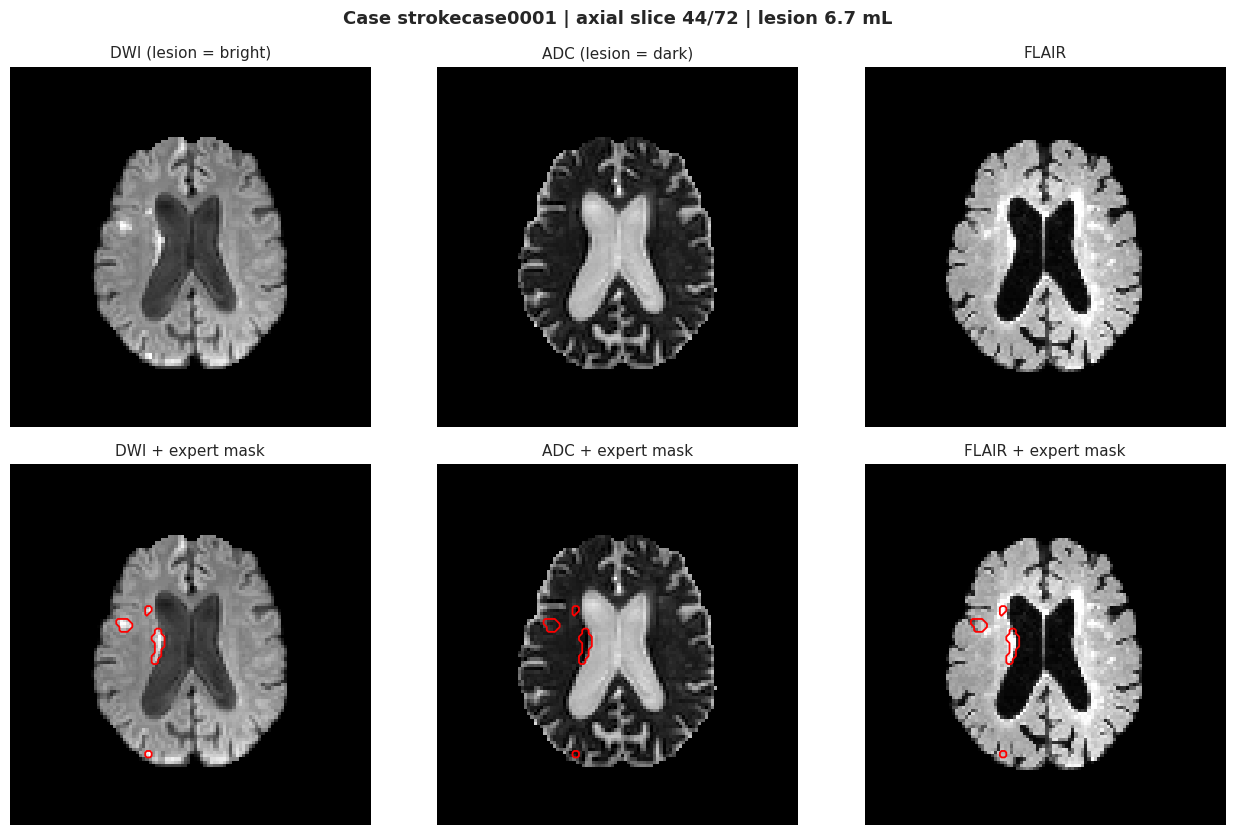

In [8]:
def load_case(row):
    """Load DWI, ADC, FLAIR, mask on the same (DWI) grid, in RAS orientation.
    Returns dict of numpy arrays + voxel spacing (mm) of the DWI grid."""
    ref = nib.as_closest_canonical(load_nifti(row.dwi))
    out = {"dwi": ref.get_fdata()}
    for name, order in [("adc", 1), ("flair", 1), ("msk", 0)]:
        img = load_nifti(row[name])
        same = img.shape == ref.shape and np.allclose(nib.as_closest_canonical(img).affine, ref.affine, atol=1e-3)
        img = nib.as_closest_canonical(img)
        out[name] = (img if same else resample_from_to(img, ref, order=order)).get_fdata()
    out["msk"] = (out["msk"] > 0.5).astype(np.uint8)
    out["spacing"] = tuple(float(z) for z in ref.header.get_zooms()[:3])
    return out

def best_slice(mask):
    """Axial slice index with the most lesion voxels (middle slice if no lesion)."""
    per_slice = mask.sum(axis=(0, 1))
    return int(per_slice.argmax()) if per_slice.max() > 0 else mask.shape[2] // 2

def axial(vol, z):
    return vol[:, :, z].T           # transpose so anterior is up, origin lower-left

def show_case(row, z=None, title=None):
    d = load_case(row)
    z = best_slice(d["msk"]) if z is None else z
    sx, sy, _ = d["spacing"]
    fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
    for j, (key, label) in enumerate([("dwi", "DWI (lesion = bright)"),
                                      ("adc", "ADC (lesion = dark)"),
                                      ("flair", "FLAIR")]):
        vol = d[key]
        brain = vol[vol > 0]
        vmin, vmax = np.percentile(brain, [1, 99]) if brain.size else (0, 1)
        for i in range(2):
            ax = axes[i, j]
            ax.imshow(axial(vol, z), cmap="gray", vmin=vmin, vmax=vmax, origin="lower", aspect=sy / sx)
            if i == 1 and d["msk"][:, :, z].any():
                ax.contour(axial(d["msk"], z), levels=[0.5], colors="red", linewidths=1.3)
            ax.set_title(label if i == 0 else label.split(" ")[0] + " + expert mask", fontsize=11)
            ax.axis("off")
    fig.suptitle(title or f"Case {row.case_id} | axial slice {z}/{d['msk'].shape[2]-1} | "
                 f"lesion {d['msk'].sum()*np.prod(d['spacing'])/1000:.1f} mL", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

show_case(complete.iloc[0])

**What you should notice:** the red outline sits on the region that is **bright in DWI**, **dark in ADC**, and usually (but not always) somewhat bright in FLAIR. Top row = raw images, bottom row = the same images with the expert mask.

### The three anatomical views
Because the data are 3D, a lesion should be checked in all three planes. Below: axial (top-down), coronal (front-back) and sagittal (side) views through the lesion centre.

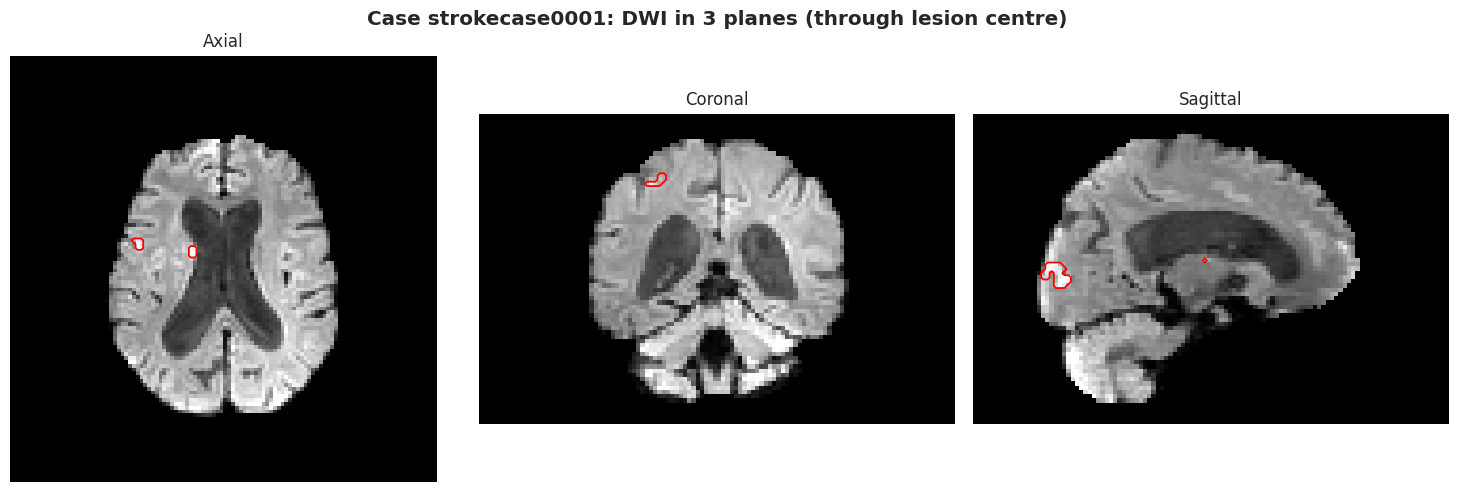

In [9]:
def show_three_planes(row):
    d = load_case(row)
    if d["msk"].sum() == 0:
        print("This case has an empty mask."); return
    cx, cy, cz = [int(round(c)) for c in ndimage.center_of_mass(d["msk"])]
    sx, sy, sz = d["spacing"]
    views = [("Axial",    d["dwi"][:, :, cz].T, d["msk"][:, :, cz].T, sy / sx),
             ("Coronal",  d["dwi"][:, cy, :].T, d["msk"][:, cy, :].T, sz / sx),
             ("Sagittal", d["dwi"][cx, :, :].T, d["msk"][cx, :, :].T, sz / sy)]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (name, img, m, asp) in zip(axes, views):
        ax.imshow(img, cmap="gray", origin="lower", aspect=asp,
                  vmin=np.percentile(img[img > 0], 1), vmax=np.percentile(img[img > 0], 99))
        if m.any(): ax.contour(m, levels=[0.5], colors="red", linewidths=1.3)
        ax.set_title(name); ax.axis("off")
    fig.suptitle(f"Case {row.case_id}: DWI in 3 planes (through lesion centre)", fontweight="bold")
    plt.tight_layout(); plt.show()

show_three_planes(complete.iloc[0])

> If the coronal / sagittal views look *stretched or blocky*, that is real: DWI has thick slices (often 5 mm) but fine in-plane resolution. We corrected the display aspect ratio using the voxel size.

## 6. Dataset-wide technical properties

Now we read the **headers of all cases** (fast — no image data needed) to answer:

* Are all images the same size? *(Almost certainly not — native space.)*
* What voxel spacings occur?
* Do DWI, ADC, FLAIR and the mask share the same grid?

This tells us how much preprocessing a model will need.

In [10]:
def header_info(row):
    imgs = {k: load_nifti(row[k]) for k in needed}
    dwi = imgs["dwi"]
    def same_grid(a, b):
        return a.shape == b.shape and bool(np.allclose(a.affine, b.affine, atol=1e-3))
    return dict(
        case_id=row.case_id,
        shape="x".join(map(str, dwi.shape)),
        nx=dwi.shape[0], ny=dwi.shape[1], nz=dwi.shape[2],
        sx=round(float(dwi.header.get_zooms()[0]), 2),
        sy=round(float(dwi.header.get_zooms()[1]), 2),
        sz=round(float(dwi.header.get_zooms()[2]), 2),
        orientation="".join(nib.aff2axcodes(dwi.affine)),
        adc_same_grid=same_grid(dwi, imgs["adc"]),
        msk_same_grid=same_grid(dwi, imgs["msk"]),
        flair_same_grid=same_grid(dwi, imgs["flair"]),
        flair_shape="x".join(map(str, imgs["flair"].shape)),
        flair_sz=round(float(imgs["flair"].header.get_zooms()[2]), 2),
    )

hdr = pd.DataFrame([header_info(r) for _, r in tqdm(complete.iterrows(), total=len(complete))])
hdr.head()

  0%|          | 0/250 [00:00<?, ?it/s]

,case_id,shape,nx,ny,nz,sx,sy,sz,orientation,adc_same_grid,msk_same_grid,flair_same_grid,flair_shape,flair_sz
0,strokecase0001,112x112x73,112,112,73,2.0,2.0,2.0,LAS,True,True,False,281x352x352,0.71
1,strokecase0002,112x112x72,112,112,72,2.0,2.0,2.0,LAS,True,True,False,281x352x352,0.71
2,strokecase0003,112x112x72,112,112,72,2.0,2.0,2.0,LAS,True,True,False,281x352x352,0.71
3,strokecase0004,112x112x72,112,112,72,2.0,2.0,2.0,LAS,True,True,False,281x352x352,0.71
4,strokecase0005,112x112x72,112,112,72,2.0,2.0,2.0,LAS,True,True,False,352x352x230,1.00


In [11]:
print("Share of cases where the image grid equals the DWI grid:")
print((hdr[["adc_same_grid", "msk_same_grid", "flair_same_grid"]].mean() * 100).round(1).astype(str) + " %")

print("\nMost common DWI shapes:")
print(hdr["shape"].value_counts().head(8))

print("\nMost common DWI voxel spacings (x, y, z in mm):")
print(hdr.groupby(["sx", "sy", "sz"]).size().sort_values(ascending=False).head(8))

print("\nOrientations:", hdr.orientation.value_counts().to_dict())

Share of cases where the image grid equals the DWI grid:
adc_same_grid      100.0 %
msk_same_grid      100.0 %
flair_same_grid      0.0 %
dtype: object

Most common DWI shapes:
shape
112x112x73    93
112x112x72    92
128x128x25    27
192x192x30    23
128x128x72     2
256x256x73     2
115x115x75     1
115x115x28     1
Name: count, dtype: int64

Most common DWI voxel spacings (x, y, z in mm):
sx    sy    sz 
2.00  2.00  2.0    193
1.80  1.80  4.8     29
1.15  1.15  4.8     23
0.88  0.88  2.0      2
1.35  1.35  4.4      1
1.97  1.97  2.0      1
2.00  2.00  5.0      1
dtype: int64

Orientations: {'LAS': 250}


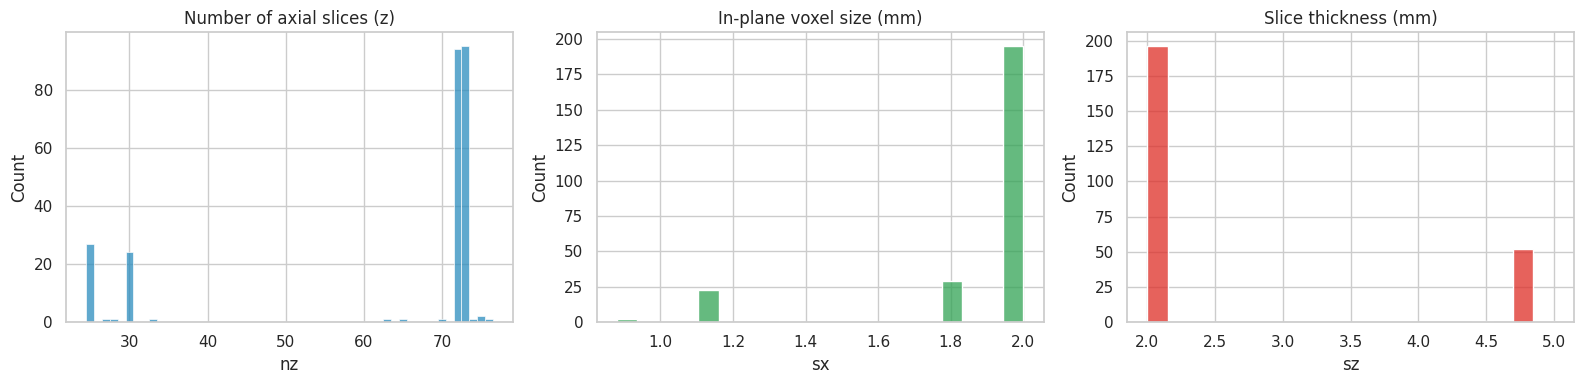

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(hdr.nz, discrete=True, ax=axes[0], color="#2b8cbe");   axes[0].set_title("Number of axial slices (z)")
sns.histplot(hdr.sx, ax=axes[1], color="#31a354", bins=20);          axes[1].set_title("In-plane voxel size (mm)")
sns.histplot(hdr.sz, ax=axes[2], color="#de2d26", bins=20);          axes[2].set_title("Slice thickness (mm)")
plt.tight_layout(); plt.show()

**Take-aways to write down for yourself**

* If `msk_same_grid` is ~100 %, the mask lives in DWI space (this is what we expect), so you can use DWI/ADC + mask directly.
* If `flair_same_grid` is low, FLAIR is a different grid → it **must be resampled** (or registered) onto DWI before stacking channels for a model.
* Many different shapes / spacings ⇒ you will need **resampling to a common spacing** and **patch-based** or **resize/crop** training.

## 7. Lesion statistics

For every case we load only the **mask** and compute:

* **lesion volume (mL)** = number of lesion voxels x voxel volume,
* **number of separate lesions** (3D connected components, 26-connectivity),
* **lesion voxels per slice** → how many slices contain the lesion.

This tells us the *class imbalance*: the lesion is a tiny fraction of the brain, which is the central difficulty of this task.

In [13]:
STRUCT_26 = np.ones((3, 3, 3), dtype=int)

def lesion_stats(row):
    img = load_nifti(row.msk)
    m = img.get_fdata() > 0
    vox_ml = float(np.prod(img.header.get_zooms()[:3])) / 1000
    n_vox = int(m.sum())
    n_comp = int(ndimage.label(m, structure=STRUCT_26)[1]) if n_vox else 0
    z_extent = int(m.any(axis=(0, 1)).sum())
    return dict(case_id=row.case_id, lesion_voxels=n_vox, lesion_ml=n_vox * vox_ml,
                n_lesions=n_comp, slices_with_lesion=z_extent,
                lesion_pct_of_volume=100 * n_vox / m.size)

les = pd.DataFrame([lesion_stats(r) for _, r in tqdm(complete.iterrows(), total=len(complete))])
stats = les.merge(hdr[["case_id", "nz", "sx", "sz"]], on="case_id")
print("Cases with EMPTY mask:", int((les.lesion_voxels == 0).sum()))
les.lesion_ml.describe().round(2).to_frame("lesion volume (mL)")

  0%|          | 0/250 [00:00<?, ?it/s]

Cases with EMPTY mask: 3


,lesion volume (mL)
count,250.00
mean,23.42
std,47.00
min,0.00
25%,1.58
50%,6.66
75%,21.17
max,482.15


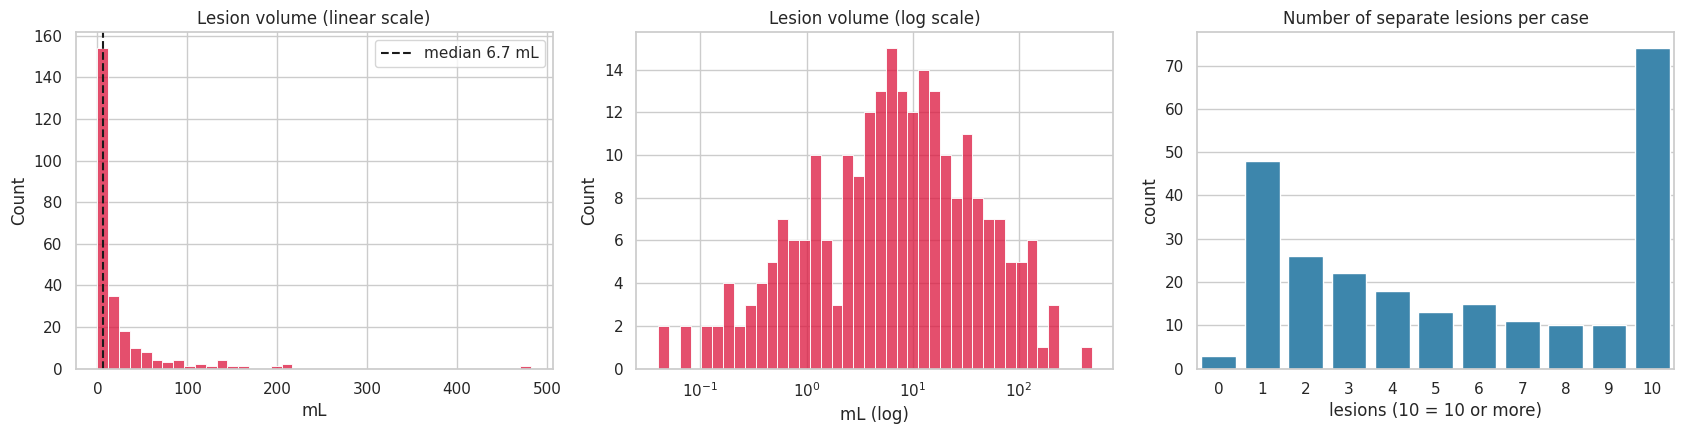

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.histplot(les.lesion_ml, bins=40, color="crimson", ax=axes[0])
axes[0].axvline(les.lesion_ml.median(), color="k", ls="--", label=f"median {les.lesion_ml.median():.1f} mL")
axes[0].set_title("Lesion volume (linear scale)"); axes[0].set_xlabel("mL"); axes[0].legend()

sns.histplot(les.lesion_ml[les.lesion_ml > 0], bins=40, log_scale=True, color="crimson", ax=axes[1])
axes[1].set_title("Lesion volume (log scale)"); axes[1].set_xlabel("mL (log)")

sns.countplot(x=les.n_lesions.clip(upper=10), color="#2b8cbe", ax=axes[2])
axes[2].set_title("Number of separate lesions per case"); axes[2].set_xlabel("lesions (10 = 10 or more)")
plt.tight_layout(); plt.show()

**How to interpret**

* The **linear** histogram is heavily right-skewed: many small strokes, few very large ones. The **log** histogram shows the shape more clearly.
* Several *separate* lesions in one patient (multi-focal strokes) are common — a model must find scattered lesions, not just one blob.

### Size groups
Small lesions are the hardest to segment. We create three groups (thresholds are a convention, not an official rule; adjust freely).

size_group
small (<10 mL)       141
medium (10-50 mL)     79
large (>50 mL)        30
Name: count, dtype: int64

Median lesion occupies only 0.098 % of the scan volume


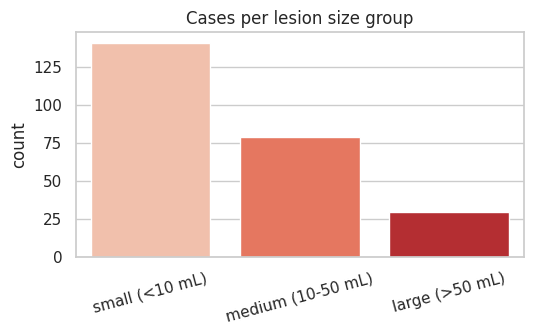


Smallest 5 lesions:


,case_id,lesion_ml,n_lesions
149,strokecase0150,0.00,0
150,strokecase0151,0.00,0
169,strokecase0170,0.00,0
5,strokecase0006,0.04,1
116,strokecase0117,0.05,2


Largest 5 lesions:


,case_id,lesion_ml,n_lesions
22,strokecase0023,482.15,9
245,strokecase0246,216.26,11
239,strokecase0240,212.41,1
61,strokecase0062,198.02,5
221,strokecase0222,163.97,4


In [15]:
bins   = [-0.01, 10, 50, np.inf]
labels = ["small (<10 mL)", "medium (10-50 mL)", "large (>50 mL)"]
les["size_group"] = pd.cut(les.lesion_ml, bins=bins, labels=labels)

print(les.size_group.value_counts().reindex(labels))
print("\nMedian lesion occupies only %.3f %% of the scan volume" % les.lesion_pct_of_volume.median())

fig, ax = plt.subplots(figsize=(5.5, 3.5))
sns.countplot(x="size_group", data=les, order=labels, palette="Reds", ax=ax)
ax.set_xlabel(""); ax.set_title("Cases per lesion size group"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

print("\nSmallest 5 lesions:"); display(les.nsmallest(5, "lesion_ml")[["case_id", "lesion_ml", "n_lesions"]].round(2))
print("Largest 5 lesions:");  display(les.nlargest(5, "lesion_ml")[["case_id", "lesion_ml", "n_lesions"]].round(2))

Let's look at the **largest** and a **small** lesion side by side, to feel the range the model must handle.

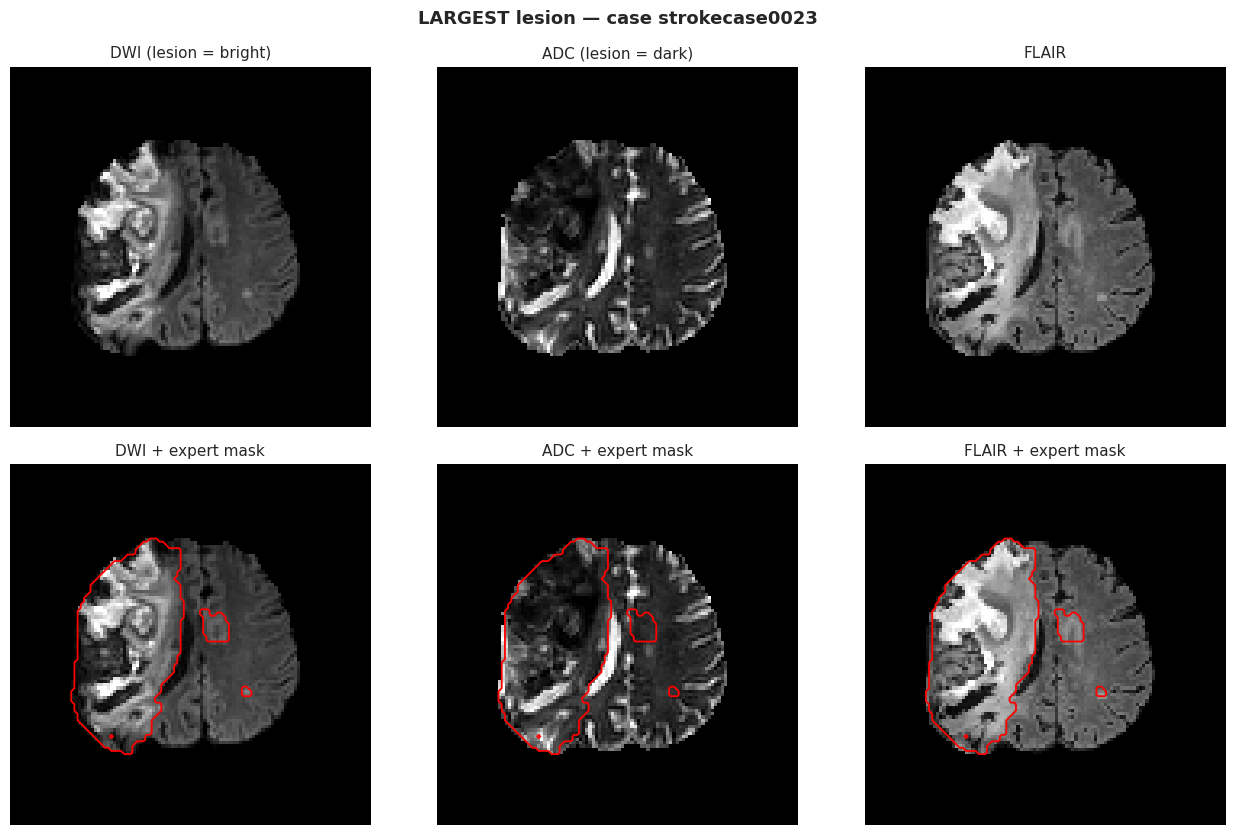

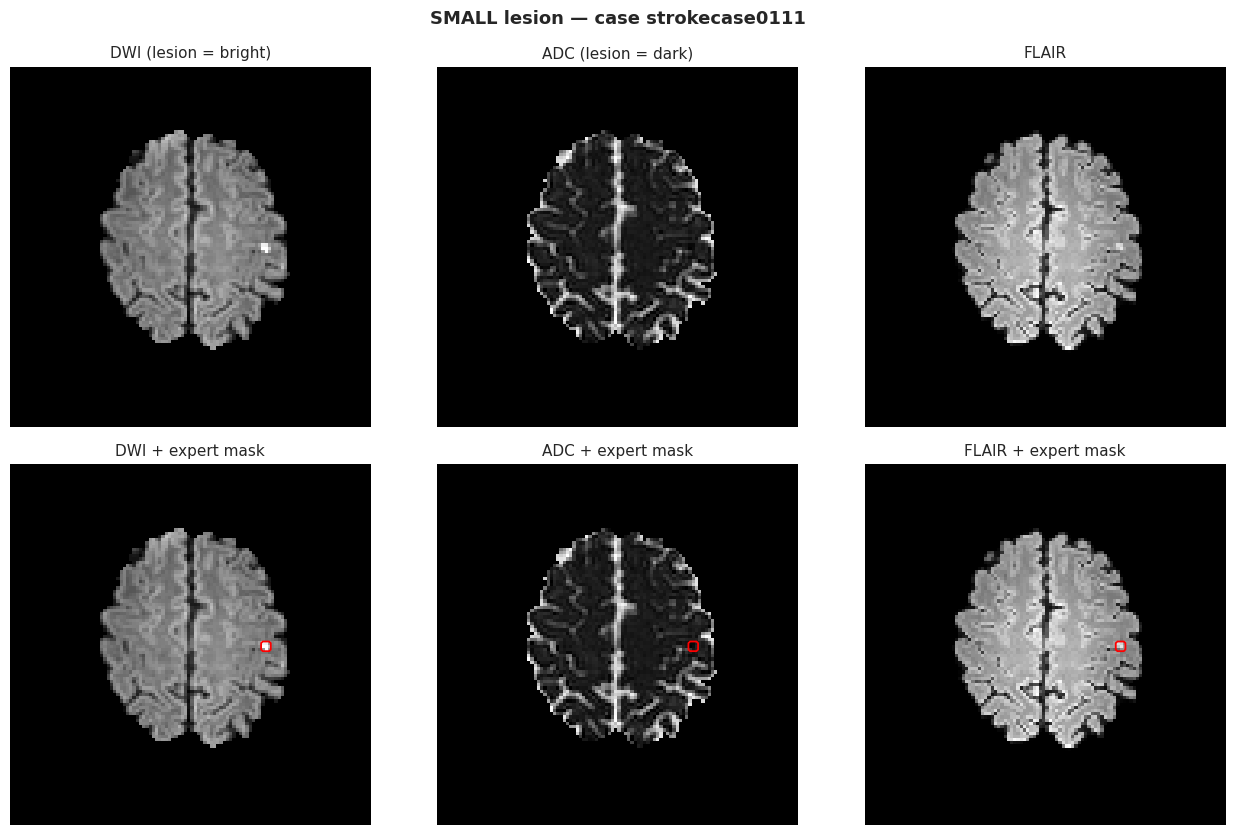

In [16]:
largest_id  = les.loc[les.lesion_ml.idxmax(), "case_id"]
small_pool  = les[(les.lesion_ml > 0)].nsmallest(max(5, len(les) // 10), "lesion_ml")
small_id    = small_pool.sample(1, random_state=SEED).case_id.iloc[0]

show_case(complete[complete.case_id == largest_id].iloc[0], title=f"LARGEST lesion — case {largest_id}")
show_case(complete[complete.case_id == small_id].iloc[0], title=f"SMALL lesion — case {small_id}")

## 8. Scanners and acquisition metadata

Data come from several scanners / field strengths. A model trained on one scanner may fail on another (*domain shift*), so it is important to know the mix. When available, each case has a `.json` sidecar copied from the DICOM header.

In [17]:
KEYS = ["Manufacturer", "ManufacturersModelName", "MagneticFieldStrength", "RepetitionTime",
        "EchoTime", "SliceThickness", "SpacingBetweenSlices"]

def read_json(p):
    if isinstance(p, str) and os.path.exists(p):
        try:
            with open(p) as f: j = json.load(f)
            return {k: j.get(k) for k in KEYS}
        except Exception:
            pass
    return {k: None for k in KEYS}

meta = pd.DataFrame([{"case_id": r.case_id, **read_json(r.dwi_json)} for _, r in complete.iterrows()])
print("Cases with a DWI json sidecar:", int(meta.Manufacturer.notna().sum()), "/", len(meta))
meta.head()

Cases with a DWI json sidecar: 129 / 250


,case_id,Manufacturer,ManufacturersModelName,MagneticFieldStrength,RepetitionTime,EchoTime,SliceThickness,SpacingBetweenSlices
0,strokecase0001,Philips Medical Systems,None,3.0,10342.983398,55.0,2.0,2.0
1,strokecase0002,None,None,NaN,NaN,NaN,NaN,NaN
2,strokecase0003,Philips Medical Systems,None,3.0,5000.000488,78.0,2.0,2.0
3,strokecase0004,None,None,NaN,NaN,NaN,NaN,NaN
4,strokecase0005,Philips Medical Systems,None,3.0,3642.065918,58.0,2.0,2.0


scanner
Philips Medical Systems ? 3.0T    124
? ? ?                             106
? ? 3.0T                           15
SIEMENS ? 3.0T                      4
Philips ? 3.0T                      1
Name: count, dtype: int64


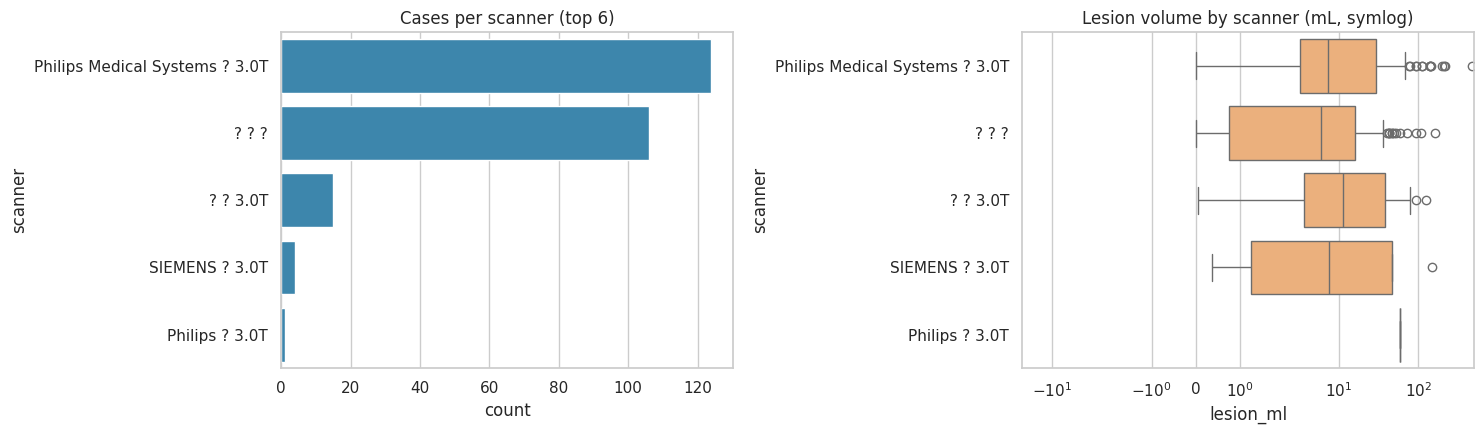

In [18]:
if meta.Manufacturer.notna().any():
    meta["scanner"] = (meta.Manufacturer.fillna("?").astype(str) + " " +
                       meta.ManufacturersModelName.fillna("?").astype(str) + " " +
                       meta.MagneticFieldStrength.map(lambda v: f"{v}T" if pd.notna(v) else "?"))
    print(meta.scanner.value_counts())

    m = meta.merge(les[["case_id", "lesion_ml"]], on="case_id")
    top = m.scanner.value_counts().index[:6]
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    sns.countplot(y="scanner", data=m[m.scanner.isin(top)], order=top, color="#2b8cbe", ax=axes[0])
    axes[0].set_title("Cases per scanner (top 6)")
    sns.boxplot(y="scanner", x="lesion_ml", data=m[m.scanner.isin(top)], order=top, color="#fdae6b", ax=axes[1])
    axes[1].set_xscale("symlog"); axes[1].set_title("Lesion volume by scanner (mL, symlog)")
    plt.tight_layout(); plt.show()
else:
    print("No scanner metadata available in this copy of the dataset — skipping this step.")

## 9. How does a lesion look in each modality? (intensity analysis)

Raw MRI intensities have **no fixed units**: they differ between scanners and even between patients. So comparing raw numbers across patients is misleading.

A robust trick: for each patient compute
**ratio = mean intensity inside lesion / mean intensity of healthy brain in the same patient.**

* ratio **> 1** → lesion brighter than normal brain,
* ratio **< 1** → lesion darker than normal brain.

Expected pattern for an acute ischemic stroke: **DWI ratio > 1**, **ADC ratio < 1**, **FLAIR ratio slightly > 1**.

In [19]:
N_INTENSITY = min(40, len(complete))           # loading full volumes is slower, so use a sample
sample = complete.sample(N_INTENSITY, random_state=SEED)

recs, pix = [], []
for _, r in tqdm(sample.iterrows(), total=len(sample)):
    d = load_case(r)
    lesion = d["msk"] > 0
    if lesion.sum() == 0:
        continue
    brain = d["dwi"] > 0                        # skull-stripped: background is exactly 0
    healthy = brain & ~lesion
    rec = {"case_id": r.case_id}
    for k in ["dwi", "adc", "flair"]:
        h, l = d[k][healthy].mean(), d[k][lesion].mean()
        rec[k + "_ratio"] = l / h if h > 0 else np.nan
    recs.append(rec)

ratios = pd.DataFrame(recs)
print(ratios[["dwi_ratio", "adc_ratio", "flair_ratio"]].describe().round(2))

  0%|          | 0/40 [00:00<?, ?it/s]

       dwi_ratio  adc_ratio  flair_ratio
count      40.00      40.00        40.00
mean        1.90       0.58         1.45
std         0.33       0.12         0.26
min         1.29       0.40         0.47
25%         1.67       0.51         1.31
50%         1.86       0.57         1.45
75%         2.09       0.63         1.60
max         3.05       0.95         1.99


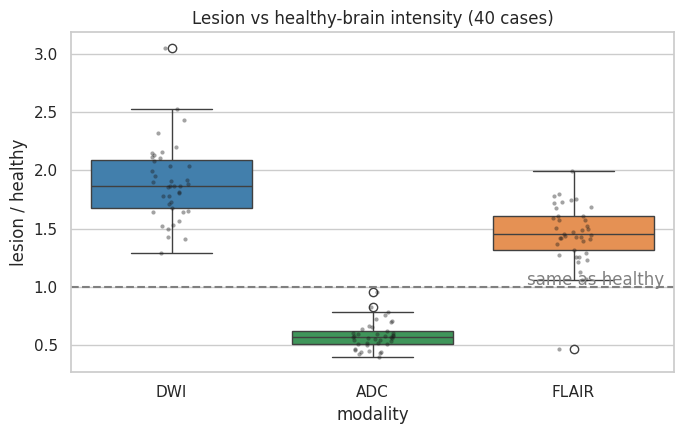

In [20]:
long = ratios.melt(id_vars="case_id", value_vars=["dwi_ratio", "adc_ratio", "flair_ratio"],
                   var_name="modality", value_name="lesion / healthy")
long["modality"] = long.modality.str.replace("_ratio", "").str.upper()

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(x="modality", y="lesion / healthy", data=long, palette=["#3182bd", "#31a354", "#fd8d3c"], ax=ax)
sns.stripplot(x="modality", y="lesion / healthy", data=long, color="k", alpha=0.4, size=3, ax=ax)
ax.axhline(1, color="gray", ls="--"); ax.text(2.45, 1.02, "same as healthy", ha="right", color="gray")
ax.set_title(f"Lesion vs healthy-brain intensity ({len(ratios)} cases)")
plt.tight_layout(); plt.show()

**Reading the chart:** a box entirely above the dashed line = the lesion is consistently brighter; entirely below = consistently darker. The wider the box, the more variable the appearance, which is what makes the task difficult.

Next, the raw intensity distributions for **one** patient (this is only meaningful within a single patient):

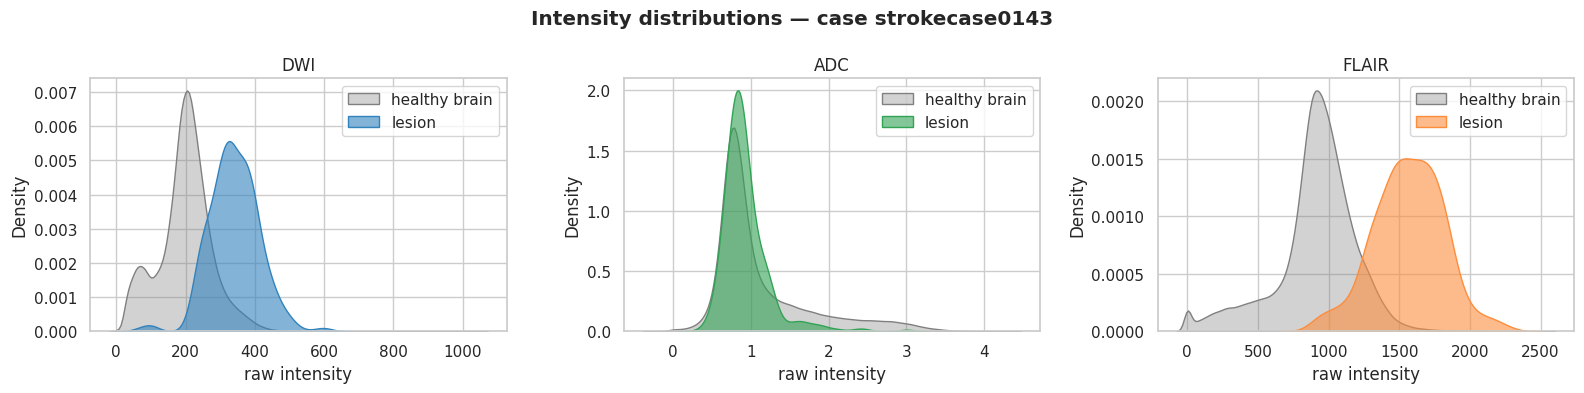

In [21]:
r0 = sample.iloc[0]
d0 = load_case(r0)
lesion0 = d0["msk"] > 0
healthy0 = (d0["dwi"] > 0) & ~lesion0

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (k, c) in zip(axes, [("dwi", "#3182bd"), ("adc", "#31a354"), ("flair", "#fd8d3c")]):
    hv = d0[k][healthy0]; lv = d0[k][lesion0]
    if lv.size:
        sns.kdeplot(hv, ax=ax, color="gray", fill=True, alpha=0.35, label="healthy brain")
        sns.kdeplot(lv, ax=ax, color=c, fill=True, alpha=0.6, label="lesion")
    ax.set_title(k.upper()); ax.set_xlabel("raw intensity"); ax.legend()
fig.suptitle(f"Intensity distributions — case {r0.case_id}", fontweight="bold")
plt.tight_layout(); plt.show()

## 10. Gallery of random cases

A quick look at 6 random patients (DWI + mask outline at the slice with the most lesion). This helps you build intuition about variety: lesion location, size, image quality, and field of view.

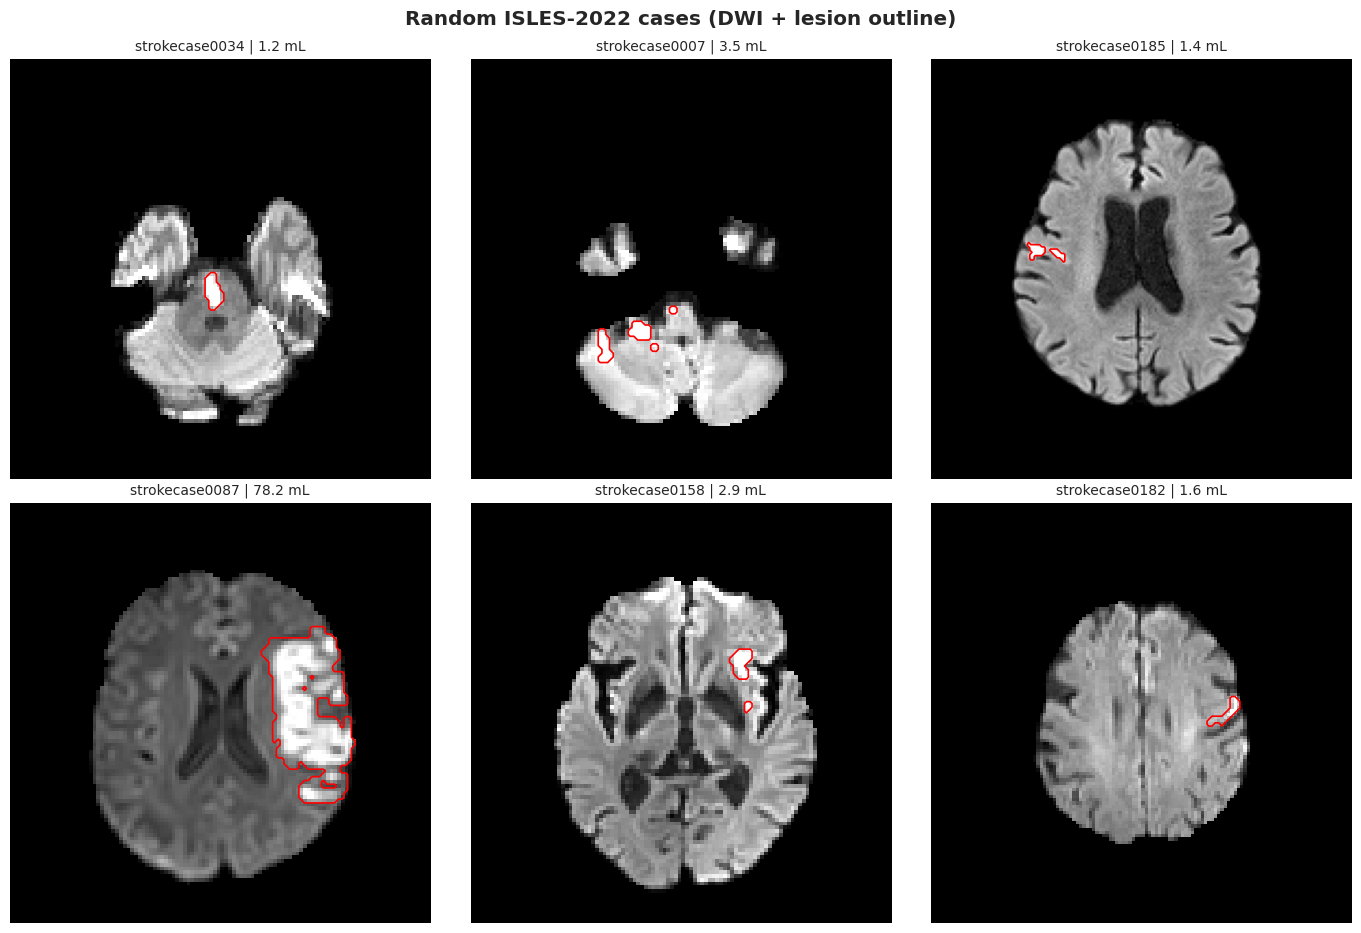

In [22]:
pick = complete[complete.case_id.isin(les[les.lesion_voxels > 0].case_id)].sample(min(6, len(complete)), random_state=SEED)

fig, axes = plt.subplots(2, 3, figsize=(14, 9.5))
for ax, (_, r) in zip(axes.ravel(), pick.iterrows()):
    d = load_case(r); z = best_slice(d["msk"]); sx, sy, _ = d["spacing"]
    v = d["dwi"][:, :, z]
    ax.imshow(v.T, cmap="gray", origin="lower", aspect=sy / sx, vmin=np.percentile(d["dwi"][d["dwi"] > 0], 1),
              vmax=np.percentile(d["dwi"][d["dwi"] > 0], 99))
    ax.contour(d["msk"][:, :, z].T, levels=[0.5], colors="red", linewidths=1.2)
    ax.set_title(f"{r.case_id} | {d['msk'].sum()*np.prod(d['spacing'])/1000:.1f} mL", fontsize=10); ax.axis("off")
plt.suptitle("Random ISLES-2022 cases (DWI + lesion outline)", fontweight="bold"); plt.tight_layout(); plt.show()

## 11. Summary table and export

We merge everything into **one summary CSV** (one row per patient) you can reuse later, for example to make a train/validation split that is balanced by lesion size.

In [23]:
summary = (complete[["case_id", "session"]]
           .merge(hdr[["case_id", "shape", "sx", "sy", "sz", "orientation", "flair_shape", "flair_same_grid", "msk_same_grid"]], on="case_id")
           .merge(les, on="case_id")
           .merge(meta.drop(columns=[c for c in ["scanner"] if c in meta.columns]), on="case_id", how="left"))

out_dir = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
out_path = os.path.join(out_dir, "isles2022_case_summary.csv")
summary.to_csv(out_path, index=False)
print("Saved:", out_path, "| shape:", summary.shape)
summary.head()

Saved: /kaggle/working/isles2022_case_summary.csv | shape: (250, 23)


,case_id,session,shape,sx,sy,sz,orientation,flair_shape,flair_same_grid,msk_same_grid,...,slices_with_lesion,lesion_pct_of_volume,size_group,Manufacturer,ManufacturersModelName,MagneticFieldStrength,RepetitionTime,EchoTime,SliceThickness,SpacingBetweenSlices
0,strokecase0001,ses-0001,112x112x73,2.0,2.0,2.0,LAS,281x352x352,False,True,...,45,0.091186,small (<10 mL),Philips Medical Systems,None,3.0,10342.983398,55.0,2.0,2.0
1,strokecase0002,ses-0001,112x112x72,2.0,2.0,2.0,LAS,281x352x352,False,True,...,8,0.013065,small (<10 mL),None,None,NaN,NaN,NaN,NaN,NaN
2,strokecase0003,ses-0001,112x112x72,2.0,2.0,2.0,LAS,281x352x352,False,True,...,43,0.428824,medium (10-50 mL),Philips Medical Systems,None,3.0,5000.000488,78.0,2.0,2.0
3,strokecase0004,ses-0001,112x112x72,2.0,2.0,2.0,LAS,281x352x352,False,True,...,22,0.031113,small (<10 mL),None,None,NaN,NaN,NaN,NaN,NaN
4,strokecase0005,ses-0001,112x112x72,2.0,2.0,2.0,LAS,352x352x230,False,True,...,26,0.080605,small (<10 mL),Philips Medical Systems,None,3.0,3642.065918,58.0,2.0,2.0


## 12. Key findings and next steps

**Fill in / verify with your own run** (numbers are printed above):

1. **Size:** number of complete cases, and whether any masks are empty.
2. **Heterogeneity:** images have different shapes and spacings (thick slices in *z*); FLAIR often lies on a different grid than DWI.
3. **Class imbalance:** the median lesion covers well under 1 % of the volume; volumes are heavily right-skewed; some patients have multiple separate lesions.
4. **Intensity:** lesions are bright in DWI, dark in ADC, mildly bright in FLAIR (patient-wise ratios in Step 9). Raw values are not comparable across patients.
5. **Scanner mix:** multiple vendors / field strengths ⇒ expect domain shift.

**Recommended preprocessing before training a segmentation model**

| Problem seen above | Standard remedy |
|---|---|
| Different shapes / spacings | Resample every case to a common spacing (e.g. 1 x 1 x 1 mm, or keep 2D / 2.5D because of thick slices) |
| FLAIR on another grid | Resample FLAIR to DWI grid (as done in `load_case`) |
| Arbitrary intensity scale | Per-volume z-score normalisation over brain voxels only (`dwi > 0`) |
| Tiny lesions, huge background | Patch sampling biased to lesion, Dice + cross-entropy (or focal) loss |
| Wide lesion-size range | Stratify train / validation split by `size_group` (from Step 7) |
| Scanner variability | Intensity augmentation; report results per scanner |

**Metrics normally used for this task:** Dice score, lesion-wise F1, absolute volume difference (mL).

*Suggested next notebook:* build a `Dataset` class that returns a normalised 3-channel tensor `[DWI, ADC, FLAIR]` and its mask, then train a baseline 3D U-Net (or nnU-Net).